In [2]:
import torch
import json
import h5py
import random
import numpy as np
from matplotlib.pyplot import imshow
from PIL import Image, ImageDraw

In [3]:
# load the following to files from DETECTED_SGG_DIR
custom_prediction = json.load(open('D:\school\pythonProject\SSG\Scene-Graph-Benchmark\output_dir\custom_prediction.json'))
custom_data_info = json.load(open('D:\school\pythonProject\SSG\Scene-Graph-Benchmark\output_dir\custom_data_info.json'))

In [4]:
def draw_single_box(pic, box, color='red', draw_info=None):
    draw = ImageDraw.Draw(pic)
    x1,y1,x2,y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
    draw.rectangle(((x1, y1), (x2, y2)), outline=color)
    if draw_info:
        draw.rectangle(((x1, y1), (x1+50, y1+10)), fill=color)
        info = draw_info
        draw.text((x1, y1), info)
        
def print_list(name, input_list, scores=None):
    for i, item in enumerate(input_list):
        if scores == None:
            print(name + ' ' + str(i) + ': ' + str(item))
        else:
            print(name + ' ' + str(i) + ': ' + str(item) + '; score: ' + str(scores[i]))
    
def draw_image(img_path, boxes, box_labels, rel_labels, box_scores=None, rel_scores=None):
    size = get_size(Image.open(img_path).size)
    pic = Image.open(img_path).resize(size)
    num_obj = len(boxes)
    for i in range(num_obj):
        info = str(i) + '_' + box_labels[i]
        draw_single_box(pic, boxes[i], draw_info=info)
    display(pic)
    print('*' * 50)
    print_list('box_labels', box_labels, box_scores)
    print('*' * 50)
    print_list('rel_labels', rel_labels, rel_scores)
    
    return None

def get_size(image_size):
    min_size = 600
    max_size = 1000
    w, h = image_size
    size = min_size
    if max_size is not None:
        min_original_size = float(min((w, h)))
        max_original_size = float(max((w, h)))
        if max_original_size / min_original_size * size > max_size:
            size = int(round(max_size * min_original_size / max_original_size))
    if (w <= h and w == size) or (h <= w and h == size):
        return (w, h)
    if w < h:
        ow = size
        oh = int(size * h / w)
    else:
        oh = size
        ow = int(size * w / h)
    return (ow, oh)

In [5]:
# parameters
image_idx = 0
box_topk = 15 # select top k bounding boxes
rel_topk = 20 # select top k relationships
ind_to_classes = custom_data_info['ind_to_classes']
ind_to_predicates = custom_data_info['ind_to_predicates']

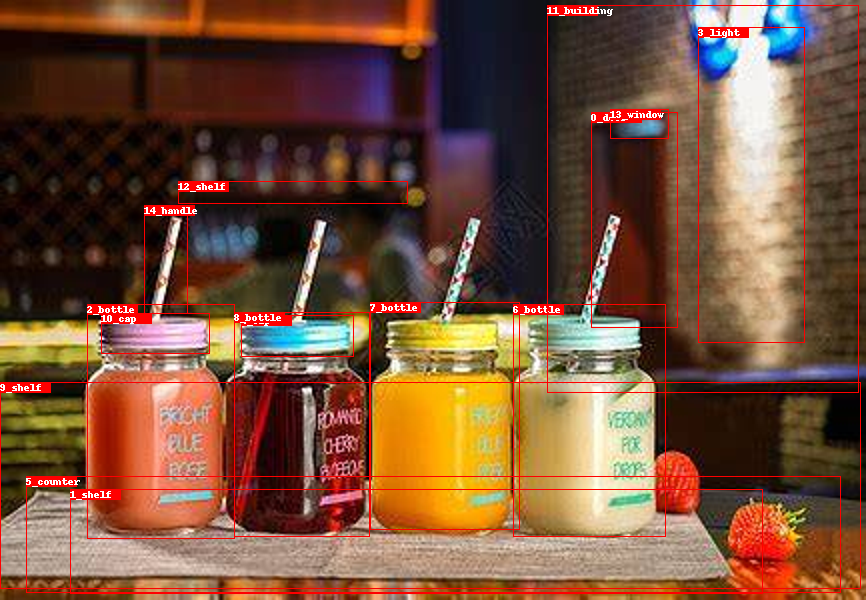

**************************************************
box_labels 0: door; score: 0.49678510427474976
box_labels 1: shelf; score: 0.36001455783843994
box_labels 2: bottle; score: 0.35292479395866394
box_labels 3: light; score: 0.28685858845710754
box_labels 4: cap; score: 0.27071812748908997
box_labels 5: counter; score: 0.2605830430984497
box_labels 6: bottle; score: 0.2484034150838852
box_labels 7: bottle; score: 0.23579086363315582
box_labels 8: bottle; score: 0.18127849698066711
box_labels 9: shelf; score: 0.16314905881881714
box_labels 10: cap; score: 0.14859706163406372
box_labels 11: building; score: 0.1277298480272293
box_labels 12: shelf; score: 0.12656603753566742
box_labels 13: window; score: 0.12105201184749603
box_labels 14: handle; score: 0.11976951360702515
**************************************************
rel_labels 0: 11_building => behind => 6_bottle; score: 0.8402974009513855
rel_labels 1: 11_building => behind => 7_bottle; score: 0.7201076745986938
rel_labels 2: 11_bui

In [ ]:
image_path = custom_data_info['idx_to_files'][image_idx]
boxes = custom_prediction[str(image_idx)]['bbox'][:box_topk]
box_labels = custom_prediction[str(image_idx)]['bbox_labels'][:box_topk]
box_scores = custom_prediction[str(image_idx)]['bbox_scores'][:box_topk]
all_rel_labels = custom_prediction[str(image_idx)]['rel_labels']
all_rel_scores = custom_prediction[str(image_idx)]['rel_scores']
all_rel_pairs = custom_prediction[str(image_idx)]['rel_pairs']

for i in range(len(box_labels)):
    box_labels[i] = ind_to_classes[box_labels[i]]

rel_labels = []
rel_scores = []
filtered_rel_pairs = []        # 新增：同步记录供图谱使用的关系对
filtered_rel_labels_idx = []   # 新增：同步记录供图谱使用的谓词索引

for i in range(len(all_rel_pairs)):
    if all_rel_pairs[i][0] < box_topk and all_rel_pairs[i][1] < box_topk:
        rel_scores.append(all_rel_scores[i])
        label = str(all_rel_pairs[i][0]) + '_' + box_labels[all_rel_pairs[i][0]] + ' => ' + ind_to_predicates[all_rel_labels[i]] + ' => ' + str(all_rel_pairs[i][1]) + '_' + box_labels[all_rel_pairs[i][1]]
        rel_labels.append(label)
        
        # 新增：将符合条件的数据存入列表
        filtered_rel_pairs.append(all_rel_pairs[i])
        filtered_rel_labels_idx.append(all_rel_labels[i])

# 统一截断前 rel_topk 条关系
rel_labels = rel_labels[:rel_topk]
rel_scores = rel_scores[:rel_topk]
filtered_rel_pairs = filtered_rel_pairs[:rel_topk]
filtered_rel_labels_idx = filtered_rel_labels_idx[:rel_topk]

# 1. 绘制原始检测框图与终端输出
draw_image(image_path, boxes, box_labels, rel_labels, box_scores=box_scores, rel_scores=rel_scores)

# 2. 新增：绘制知识图谱
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for pair, pred_idx in zip(filtered_rel_pairs, filtered_rel_labels_idx):
    subj_idx = pair[0]
    obj_idx = pair[1]
    
    subj_name = f"{box_labels[subj_idx]}_{subj_idx}"
    obj_name = f"{box_labels[obj_idx]}_{obj_idx}"
    predicate = ind_to_predicates[pred_idx]
    
    G.add_edge(subj_name, obj_name, label=predicate)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1.5, seed=42)

nx.draw(G, pos,
        with_labels=True,
        node_color='#87CEFA',
        node_size=2500,
        edge_color='gray',
        font_size=10,
        font_weight='bold',
        arrows=True,
        arrowsize=15)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10)

plt.title("Scene Graph Knowledge Graph", fontsize=15)
plt.show()